<a href="https://colab.research.google.com/github/rumanz22/Customer-Segmentation-Revenue-Optimization-Using-Transaction-Data/blob/main/marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/online_retail.csv")


In [ ]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:

# 1. Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. Remove missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

# 3. Keep only positive Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Reset index
df = df.reset_index(drop=True)

# Preview cleaned data
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
397879    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
397880    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
397881    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
397882    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
397883    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Country  
0     

In [ ]:
# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Compute total spend per row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Reference date for recency (e.g., the latest date in dataset + 1 day)
import datetime
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate to customer level
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# Preview RFM table
print(rfm)

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
...             ...        ...       ...
18280.0         278          1    180.60
18281.0         181          1     80.82
18282.0           8          2    178.05
18283.0           4         16   2094.88
18287.0          43          3   1837.28

[4338 rows x 3 columns]


In [ ]:
import pandas as pd

# Assuming 'rfm' DataFrame is already created from previous step

# 1. Define thresholds for segmentation
# You can adjust these based on your dataset distribution

# Recency threshold (days)
recency_threshold_high = 30   # Last purchase within 30 days → recent
recency_threshold_medium = 90 # Last purchase within 90 days → moderate

# Frequency threshold
frequency_high = 5            # More than 5 purchases → frequent
frequency_medium = 2          # 2–5 purchases → regular

# Monetary threshold
monetary_high = 500           # Total spend >500 → high-value
monetary_medium = 100         # Total spend 100–500 → medium-value

# 2. Define a function to segment customers
def customer_segment(row):
    if row['Frequency'] > frequency_high and row['Monetary'] > monetary_high:
        return 'High-value customer'
    elif row['Frequency'] >= frequency_medium and row['Monetary'] >= monetary_medium:
        return 'Regular customer'
    elif row['Frequency'] == 1:
        return 'One-time buyer'
    else:
        return 'Low-value customer'

# 3. Apply the segmentation
rfm['CustomerSegment'] = rfm.apply(customer_segment, axis=1)

# Preview segmentation
print(rfm)


            Recency  Frequency  Monetary      CustomerSegment
CustomerID                                                   
12346.0         326          1  77183.60       One-time buyer
12347.0           2          7   4310.00  High-value customer
12348.0          75          4   1797.24     Regular customer
12349.0          19          1   1757.55       One-time buyer
12350.0         310          1    334.40       One-time buyer
...             ...        ...       ...                  ...
18280.0         278          1    180.60       One-time buyer
18281.0         181          1     80.82       One-time buyer
18282.0           8          2    178.05     Regular customer
18283.0           4         16   2094.88  High-value customer
18287.0          43          3   1837.28     Regular customer

[4338 rows x 4 columns]


/tmp/ipython-input-4288265355.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values, palette='viridis')


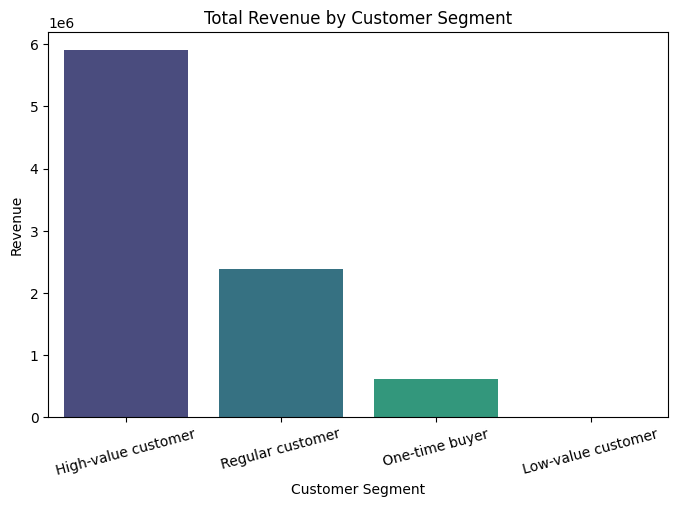

                     SegmentSize  TotalRevenue  AvgRevenuePerCustomer
CustomerSegment                                                      
High-value customer          867   5904597.820            6810.378108
Regular customer            1963   2389422.293            1217.229900
One-time buyer              1493    616311.731             412.800891
Low-value customer            15      1076.060              71.737333


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample rfm DataFrame for reference
# rfm = pd.DataFrame({
#     'Recency': [10, 20, 200, 50],
#     'Frequency': [10, 3, 1, 2],
#     'Monetary': [1000, 300, 50, 150],
#     'CustomerSegment': ['High-value customer', 'Regular customer', 'One-time buyer', 'Regular customer']
# })

# 1. Bar chart of total revenue by segment
revenue_by_segment = rfm.groupby('CustomerSegment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values, palette='viridis')
plt.title("Total Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.xlabel("Customer Segment")
plt.xticks(rotation=15)
plt.show()

# 2. Table showing segment size vs revenue
segment_summary = rfm.groupby('CustomerSegment').agg(
    SegmentSize=('CustomerSegment', 'count'),
    TotalRevenue=('Monetary', 'sum'),
    AvgRevenuePerCustomer=('Monetary', 'mean')
).sort_values(by='TotalRevenue', ascending=False)

print(segment_summary)



Key Observations:

High-value customers are few (867) but contribute ~5.9M revenue, far higher than any other segment.

Regular customers (1,963) generate only ~2.39M, less than half of high-value despite being more than double in number.

One-time buyers are large in number but contribute very little revenue.

Low-value customers are negligible and can be ignored for targeting.

Conclusion:
Focusing marketing only on high-value customers is short-term good, but the bigger opportunity is moving regular customers into high-value—i.e., increasing purchase frequency

2. Actionable Marketing Recommendations
A. Transform Regular Customers → High-Frequency Buyers

Strategies:

Loyalty Programs / Points System

Reward repeat purchases (e.g., discounts after 3 purchases).

Email & SMS Campaigns

Personalized offers for regular buyers (“You purchased X last time, here’s a related product”).

Upsell & Cross-sell Campaigns

Recommend complementary products to increase basket size and frequency.

Limited-Time Promotions

Encourage repeat purchase within a set period.

In [ ]:
import pandas as pd

# Assuming rfm DataFrame already exists and has:
# Columns: Recency, Frequency, Monetary, CustomerSegment

# 1. Filter regular customers
regular_customers = rfm[rfm['CustomerSegment'] == 'Regular customer'].copy()

# 2. Define thresholds for “high-value” (these should match the previous segmentation)
frequency_high = 5       # frequency threshold for high-value
monetary_high = 500      # monetary threshold for high-value
recency_low = 30         # lower recency means more recent purchase

# 3. Compute a "potential score"
# The closer a customer is to high-value thresholds, the higher the score
regular_customers['PotentialScore'] = (
    (regular_customers['Frequency'] / frequency_high) +
    (regular_customers['Monetary'] / monetary_high) +
    (recency_low / (regular_customers['Recency'] + 1))  # recent purchase boosts score
)

# 4. Sort by PotentialScore descending
potential_high_value = regular_customers.sort_values(by='PotentialScore', ascending=False)

# 5. Take top N potential customers (optional, e.g., top 10)
top_potential_customers = potential_high_value.head(10)

# Preview
print(top_potential_customers[['Recency', 'Frequency', 'Monetary', 'PotentialScore']])


            Recency  Frequency   Monetary  PotentialScore
CustomerID                                               
16446.0           1          2  168472.50      352.345000
15749.0         235          3   44534.30       89.795719
15098.0         182          3   39916.50       80.596934
16000.0           3          3   12393.70       32.887400
12557.0          16          5   11990.96       26.746626
12536.0          43          3   12601.83       26.485478
13680.0           1          4    3722.42       23.244840
12409.0          79          3   11072.67       23.120340
15484.0           1          4    3594.31       22.988620
12451.0          11          5    9035.52       21.571040


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming rfm DataFrame exists with:
# Columns: Recency, Frequency, Monetary, CustomerSegment

# 1. Filter regular customers
regular_customers = rfm[rfm['CustomerSegment'] == 'Regular customer'].copy()

# 2. Normalize RFM metrics for scoring
scaler = MinMaxScaler()
regular_customers[['Recency_norm', 'Frequency_norm', 'Monetary_norm']] = scaler.fit_transform(
    regular_customers[['Recency', 'Frequency', 'Monetary']]
)

# 3. Compute a PotentialScore
# We want: high Frequency, high Monetary, low Recency
regular_customers['PotentialScore'] = (
    regular_customers['Frequency_norm'] * 0.4 +
    regular_customers['Monetary_norm'] * 0.4 +
    (1 - regular_customers['Recency_norm']) * 0.2  # low recency gets higher score
)

# 4. Flag top potential customers (e.g., top 20%)
threshold = regular_customers['PotentialScore'].quantile(0.8)
regular_customers['HighPotential'] = regular_customers['PotentialScore'] >= threshold

# 5. Sort by PotentialScore descending
regular_customers = regular_customers.sort_values(by='PotentialScore', ascending=False)

# 6. Preview top potential buyers
top_potential_customers = regular_customers[regular_customers['HighPotential']]

print(top_potential_customers[['Recency', 'Frequency', 'Monetary', 'PotentialScore', 'HighPotential']])


            Recency  Frequency   Monetary  PotentialScore  HighPotential
CustomerID                                                              
16446.0           1          2  168472.50        0.600000           True
17988.0          12          7     201.12        0.594324           True
16500.0           5          6     400.86        0.518562           True
16668.0          15          6     306.72        0.512962           True
12557.0          16          5   11990.96        0.460183           True
...             ...        ...        ...             ...            ...
14467.0          18          4     598.76        0.352043           True
15530.0          22          4    1502.35        0.352039           True
17147.0          23          4    1714.59        0.352006           True
15983.0          22          4    1475.02        0.351974           True
13167.0          19          4     791.33        0.351963           True

[393 rows x 5 columns]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assume regular_customers DataFrame from previous step
# Features: RFM metrics
X = regular_customers[['Recency', 'Frequency', 'Monetary']]
# Target: HighPotential (True/False)
y = regular_customers['HighPotential']

# 1. Train/Test split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Check sizes
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (1374, 3) (1374,)
Test set: (589, 3) (589,)


Classification Report:

              precision    recall  f1-score   support

       False       1.00      0.97      0.99       471
        True       0.91      0.99      0.95       118

    accuracy                           0.98       589
   macro avg       0.95      0.98      0.97       589
weighted avg       0.98      0.98      0.98       589

Confusion Matrix:

[[459  12]
 [  1 117]]
ROC AUC Score: 0.9995681744575192


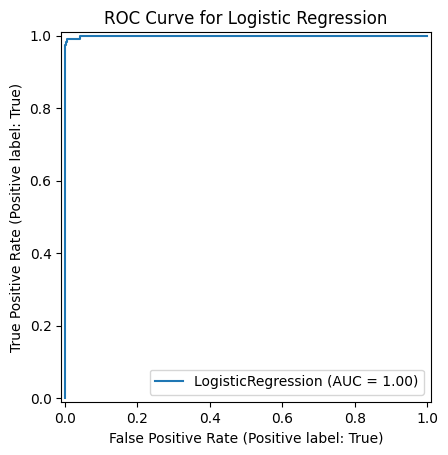

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Features and target
X = regular_customers[['Recency', 'Frequency', 'Monetary']]
y = regular_customers['HighPotential']

# 2. Train/Test split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]  # probability of class True

# 6. Evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", roc_auc)

# 7. Plot ROC Curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve for Logistic Regression")
plt.show()


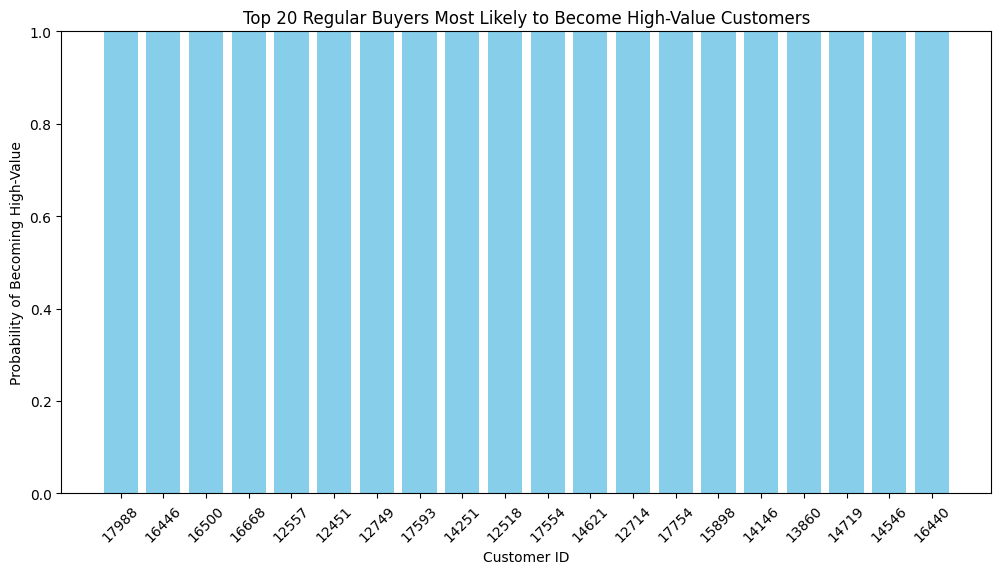

In [ ]:
# Ensure CustomerID is a column
regular_customers = regular_customers.reset_index()

# Add predicted probability
X_scaled = scaler.transform(regular_customers[['Recency', 'Frequency', 'Monetary']])
regular_customers['PredictedProbability'] = model.predict_proba(X_scaled)[:,1]

# Sort top 20
top_20_customers = regular_customers.sort_values(by='PredictedProbability', ascending=False).head(20)

# Create labels
top_20_customers['CustomerLabel'] = top_20_customers['CustomerID'].astype(int).astype(str)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(top_20_customers['CustomerLabel'], top_20_customers['PredictedProbability'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Probability of Becoming High-Value")
plt.xlabel("Customer ID")
plt.title("Top 20 Regular Buyers Most Likely to Become High-Value Customers")
plt.ylim(0,1)
plt.show()


In [ ]:
!pip install plotly pandas


In [ ]:
import pandas as pd

# Example DataFrame (replace this with your actual Colab DataFrame)
data = {
    'CustomerSegment': ['High-value customer', 'Regular customer', 'One-time buyer', 'Low-value customer'],
    'SegmentSize': [867, 1963, 1493, 15],
    'TotalRevenue': [5904597.82, 2389422.29, 616311.73, 1076.06],
    'AvgRevenuePerCustomer': [6810.38, 1217.23, 412.80, 71.73]
}
df = pd.DataFrame(data)
df


,CustomerSegment,SegmentSize,TotalRevenue,AvgRevenuePerCustomer
0,High-value customer,867,5904597.82,6810.38
1,Regular customer,1963,2389422.29,1217.23
2,One-time buyer,1493,616311.73,412.80
3,Low-value customer,15,1076.06,71.73


In [ ]:
import plotly.express as px

# 1️⃣ Bar chart: Segment Size vs Total Revenue
fig1 = px.bar(df, x='CustomerSegment', y='TotalRevenue',
              title='Total Revenue by Customer Segment',
              text='TotalRevenue',
              color='CustomerSegment')

fig1.show()

# 2️⃣ Pie chart: Revenue Contribution by Segment
fig2 = px.pie(df, names='CustomerSegment', values='TotalRevenue',
              title='Revenue Contribution by Segment')
fig2.show()

# 3️⃣ Bar chart: Average Revenue per Customer
fig3 = px.bar(df, x='CustomerSegment', y='AvgRevenuePerCustomer',
              title='Average Revenue per Customer by Segment',
              color='CustomerSegment',
              text='AvgRevenuePerCustomer')
fig3.show()


In [ ]:
# Example top regular buyers (replace with your scoring)
top_regular = pd.DataFrame({
    'CustomerID': [101,102,103,104,105],
    'Score': [0.95,0.92,0.91,0.89,0.88],
    'Monetary': [1500,1200,1300,1100,1150]
})

fig4 = px.bar(top_regular, x='CustomerID', y='Score',
              title='Top Regular Customers by Score',
              text='Score', color='Score')
fig4.show()
